# Preprocessing & Feature Preparation

## 1. Setup & Imports

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "src").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle

from src.utils.config import DATA_DIR, RESULTS_DIR, FEATURE_BLOCK_WEIGHTS

print(f" Data directory: {DATA_DIR}")
print(f" Results directory: {RESULTS_DIR}")

 Data directory: h:\My Drive\UW\2026S Recent Developments in Knowledge Discovery in Databases\RDK Project\Data
 Results directory: h:\My Drive\UW\2026S Recent Developments in Knowledge Discovery in Databases\RDK Project\results


## 2. Method 1 (Feature-Ward pipeline) preprocessing

Prepare the 2023 panel for feature-based clustering:

- validate and clean negative / missing values if needed
- identify degenerate households (all-zero, near-constant, zero-heavy)
- exclude degenerate households from the main Method 1 fit
- retain consumption spikes/outliers by design, because they may represent real behaviour relevant for clustering

In [2]:
from src.utils.data_loader import load_train_data

train_data = load_train_data()
print("2023 shape:", train_data.shape)

2023 shape: (17547, 365)


In [3]:
from src.utils.data_loader import validate_data

train_validation = validate_data(train_data, year=2023)
display(pd.DataFrame([train_validation]))

,n_households,n_days,missing_values,negative_values,zero_values,duplicate_household_ids,min_consumption,max_consumption
0,17547,365,0,0,168566,0,0.0,1051.739571


In [4]:
print(f"Households: {train_data.shape[0]:,}")
print(f"Days: {train_data.shape[1]}")
print(f"Memory usage: {train_data.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
display(train_data.iloc[:5, :10])

Households: 17,547
Days: 365
Memory usage: 49.00 MB


,2023-01-01,2023-01-02,2023-01-03,2023-01-04,2023-01-05,2023-01-06,2023-01-07,2023-01-08,2023-01-09,2023-01-10
ID,,,,,,,,,,
22,13.482,9.473,10.146,10.978,14.149,11.536,7.767,10.081,9.189,14.919
42,46.427,49.369,40.441,38.126,40.902,28.853,23.482,42.429,43.268,36.268
56,9.088,9.300,8.860,13.168,8.341,8.592,14.704,13.383,8.189,8.156
58,10.040,7.633,11.596,8.036,10.404,6.576,8.617,15.368,8.773,6.134
64,2.969,2.427,2.018,2.742,2.118,2.879,1.961,2.161,2.256,3.755


In [5]:
from src.utils.config import RANDOM_SEED
from src.preprocessing.data_cleaning import DataCleaner

cleaner = DataCleaner(random_seed=RANDOM_SEED)
feature_input, feature_prep_summary, feature_prep_details = cleaner.prepare_for_feature_clustering(train_data)
print("feature_input semantics: cleaned regular-household time-series rows for Method 1 feature extraction")

print("Rows for Method 1 fit:", feature_prep_summary["n_regular_for_fit"])
print("Degenerate households excluded:", feature_prep_summary["n_degenerate_excluded"])
display(pd.DataFrame([feature_prep_summary]))

feature_input semantics: cleaned regular-household time-series rows for Method 1 feature extraction
Rows for Method 1 fit: 17224
Degenerate households excluded: 323


,intended_method,negatives,missing,degenerate_flags,n_cleaned_total,n_regular_for_fit,n_degenerate_excluded,transform,normalization,excluded_special_regimes_from_fit,scope_note,outlier_handling_applied,outlier_policy_note,output_semantics
0,feature_ward,"{'negatives_before': 0, 'negatives_after': 0, ...","{'missing_before': 0, 'missing_after': 0, 'str...","{'all_zero': 154, 'near_constant': 75, 'zero_h...",17547,17224,323,none,None,"{'all_zero': True, 'near_constant': True, 'zer...",Feature-Ward and k-Shape are fit on the same s...,False,Outliers are retained by design because consum...,Returns cleaned household time-series rows for...


In [6]:
print("Outlier handling applied:", feature_prep_summary.get("outlier_handling_applied"))
print("Outlier policy note:", feature_prep_summary.get("outlier_policy_note"))

Outlier handling applied: False
Outlier policy note: Outliers are retained by design because consumption spikes may reflect real household behaviour that is relevant for clustering.


### 2.1 Before vs After Cleaning Comparison

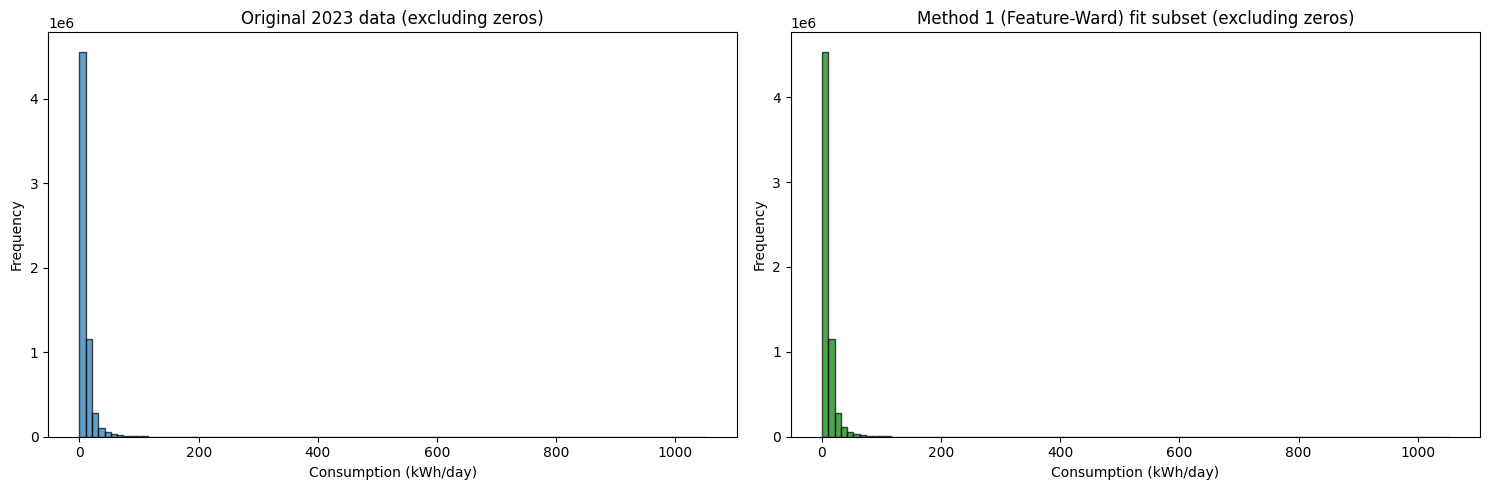


Original 2023 panel shape: (17547, 365)
Method 1 (Feature-Ward) fit subset shape: (17224, 365)
Excluded households: 323


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

all_values_before = train_data.values.flatten()
all_values_after = feature_input.values.flatten()

axes[0].hist(all_values_before[all_values_before > 0], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_title('Original 2023 data (excluding zeros)')
axes[0].set_xlabel('Consumption (kWh/day)')
axes[0].set_ylabel('Frequency')

axes[1].hist(all_values_after[all_values_after > 0], bins=100, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Method 1 (Feature-Ward) fit subset (excluding zeros)')
axes[1].set_xlabel('Consumption (kWh/day)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print("\nOriginal 2023 panel shape:", train_data.shape)
print("Method 1 (Feature-Ward) fit subset shape:", feature_input.shape)
print("Excluded households:", train_data.shape[0] - feature_input.shape[0])

## 3. Feature Extraction


In [8]:
from src.preprocessing.feature_engineering import FeatureEngineer

engineer = FeatureEngineer(random_seed=RANDOM_SEED)
final_ward_features, feature_metadata = engineer.extract_final_feature_ward_features(
    feature_input,
    return_metadata=True,
)

print("Main Method 1 (Feature-Ward pipeline) feature shape:", final_ward_features.shape)
display(engineer.summarize_feature_groups())
display(pd.DataFrame(list(FEATURE_BLOCK_WEIGHTS.items()), columns=["feature_block", "weight"]))

Main Method 1 (Feature-Ward pipeline) feature shape: (17224, 36)


,block,n_features,features
0,level_dispersion,1,cv
1,weekly,2,"autocorr_lag_7, weekday_range"
2,energy_profile,6,"winter_share, summer_share, top3_month_share, ..."
3,persistence,3,"autocorr_lag_30, rolling_std_7, diff_std"
4,trend,1,trend_slope_normalized
5,shape_normalized,23,"norm_dow_Mon, norm_dow_Tue, norm_dow_Wed, norm..."


,feature_block,weight
0,level_dispersion,0.15
1,weekly,0.85
2,energy_profile,0.85
3,persistence,0.70
4,trend,0.25
5,shape_normalized,1.25


In [9]:
feature_block_map_table = pd.DataFrame({
    "feature_block": list(feature_metadata["feature_blocks"].keys()),
    "columns": [", ".join(cols[:8]) + (" ..." if len(cols) > 8 else "") for cols in feature_metadata["feature_blocks"].values()],
})
display(feature_block_map_table)

,feature_block,columns
0,level_dispersion,cv
1,weekly,"autocorr_lag_7, weekday_range"
2,energy_profile,"winter_share, summer_share, top3_month_share, ..."
3,persistence,"autocorr_lag_30, rolling_std_7, diff_std"
4,trend,trend_slope_normalized
5,shape_normalized,"norm_dow_Mon, norm_dow_Tue, norm_dow_Wed, norm..."


### 3.1 Feature block summary

In [10]:
feature_block_summary = engineer.summarize_feature_groups()
display(feature_block_summary)

feature_block_counts = pd.DataFrame({
    "feature_block": list(feature_metadata["feature_blocks"].keys()),
    "n_features": [len(cols) for cols in feature_metadata["feature_blocks"].values()],
})
display(feature_block_counts)

,block,n_features,features
0,level_dispersion,1,cv
1,weekly,2,"autocorr_lag_7, weekday_range"
2,energy_profile,6,"winter_share, summer_share, top3_month_share, ..."
3,persistence,3,"autocorr_lag_30, rolling_std_7, diff_std"
4,trend,1,trend_slope_normalized
5,shape_normalized,23,"norm_dow_Mon, norm_dow_Tue, norm_dow_Wed, norm..."


,feature_block,n_features
0,level_dispersion,1
1,weekly,2
2,energy_profile,6
3,persistence,3
4,trend,1
5,shape_normalized,23


## 4. Feature preparation for clustering

In [11]:
from src.preprocessing.feature_selection import FeatureSelector
from src.utils.config import FEATURE_USE_PCA

selector = FeatureSelector(random_seed=RANDOM_SEED)
prepared = selector.prepare_feature_method_input(
    features=final_ward_features,
    feature_block_map=feature_metadata["feature_blocks"],
    use_pca=FEATURE_USE_PCA,
)

print("Method 1 (Feature-Ward pipeline) preparation summary:")
display(pd.DataFrame([prepared["summary"]]))

print("Selection pipeline summary:")
display(selector.summarize_selection())

Method 1 (Feature-Ward pipeline) preparation summary:


,n_original_features,n_after_low_variance_filter,n_after_correlation_filter,n_final_clustering_dimensions,low_variance_removed,correlated_removed,selected_feature_names,scale_method,used_pca,pca_explained_variance,pca_n_components,sanitize_summary,used_feature_block_weights,retained_feature_blocks,feature_block_weights,retained_block_counts
0,36,36,34,34,[],"[diff_std, top3_month_share]","[cv, autocorr_lag_7, norm_dow_Mon, norm_dow_Tu...",standard,False,None,None,"{'nan_imputed_columns': [], 'n_nan_imputed_col...",True,"{'level_dispersion': ['cv'], 'weekly': ['autoc...","{'level_dispersion': 0.15, 'weekly': 0.85, 'en...","[{'block': 'level_dispersion', 'n_original': 1..."


Selection pipeline summary:


,stage,count
0,nan_imputed_columns,0
1,inf_replaced_columns,0
2,low_variance_removed,0
3,correlated_removed,2
4,selected_features,34
5,pca_components,34


In [12]:
retained_blocks = selector.get_retained_feature_blocks()
display(pd.DataFrame(
    {
        "block": list(retained_blocks.keys()),
        "retained_columns": [", ".join(v) for v in retained_blocks.values()],
        "n_retained": [len(v) for v in retained_blocks.values()],
    }
))

,block,retained_columns,n_retained
0,level_dispersion,cv,1
1,weekly,"autocorr_lag_7, weekday_range",2
2,energy_profile,"winter_share, summer_share, monthly_entropy, p...",5
3,persistence,"autocorr_lag_30, rolling_std_7",2
4,trend,trend_slope_normalized,1
5,shape_normalized,"norm_dow_Mon, norm_dow_Tue, norm_dow_Wed, norm...",23


## 5. PCA 

In [13]:
if selector.pca_model is not None:
    loadings = selector.get_pca_loadings()
    top_pca_features = selector.get_top_pca_features(top_n=10)

    for pc, series in list(top_pca_features.items())[:5]:
        print(f"\n{pc}")
        display(series)

In [14]:
if selector.pca_model is not None:
    explained = selector.pca_model.explained_variance_ratio_
    plt.figure(figsize=(8, 4))
    plt.plot(np.arange(1, len(explained) + 1), np.cumsum(explained), marker="o")
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.title("PCA cumulative explained variance (Method 1: Feature-Ward)")
    plt.grid(True)
    plt.show()

In [15]:
if selector.pca_model is not None:
    top_features = selector.get_top_pca_features(top_n=8)
    for pc, series in list(top_features.items())[:3]:
        print(f"\n{pc}")
        display(series)
else:
    print("PCA is disabled for the current Method 1 pipeline.")

PCA is disabled for the current Method 1 pipeline.


## 6. Export Method 1 (Feature-Ward pipeline) artifacts

In [16]:
import os
output_dir = RESULTS_DIR

main_features_path = os.path.join(output_dir, "method1_final_ward_features.csv")
filtered_features_path = os.path.join(output_dir, "method1_filtered_features.csv")
clustering_input_path = os.path.join(output_dir, "method1_clustering_input.csv")
weighted_features_path = os.path.join(output_dir, "method1_weighted_features.csv")

final_ward_features.to_csv(main_features_path)
prepared["filtered_features"].to_csv(filtered_features_path)
prepared["clustering_input"].to_csv(clustering_input_path)

if selector.pca_model is not None:
    pca_loadings_path = os.path.join(output_dir, "method1_pca_loadings.csv")
    selector.get_pca_loadings().to_csv(pca_loadings_path)
else:
    pca_loadings_path = None

print("Saved Method 1 (Feature-Ward pipeline) artifacts:")
print(" -", main_features_path)
print(" -", filtered_features_path)
print(" -", clustering_input_path)
print(" -", weighted_features_path)
if pca_loadings_path is not None:
    print(" -", pca_loadings_path)

Saved Method 1 (Feature-Ward pipeline) artifacts:
 - h:\My Drive\UW\2026S Recent Developments in Knowledge Discovery in Databases\RDK Project\results\method1_final_ward_features.csv
 - h:\My Drive\UW\2026S Recent Developments in Knowledge Discovery in Databases\RDK Project\results\method1_filtered_features.csv
 - h:\My Drive\UW\2026S Recent Developments in Knowledge Discovery in Databases\RDK Project\results\method1_clustering_input.csv
 - h:\My Drive\UW\2026S Recent Developments in Knowledge Discovery in Databases\RDK Project\results\method1_weighted_features.csv


## 7. Final Method 1 preprocessing summary

In [17]:
summary = prepared["summary"]
final_summary = pd.DataFrame({
    "metric": [
        "fit_households",
        "original_features",
        "features_after_low_variance",
        "features_after_correlation",
        "final_clustering_dimensions",
        "used_pca",
        "used_feature_block_weights",
        "degenerate_households_excluded",
    ],
    "value": [
        feature_prep_summary["n_regular_for_fit"],
        summary["n_original_features"],
        summary["n_after_low_variance_filter"],
        summary["n_after_correlation_filter"],
        summary["n_final_clustering_dimensions"],
        summary["used_pca"],
        summary["used_feature_block_weights"],
        feature_prep_summary["n_degenerate_excluded"],
    ],
})
display(final_summary)

,metric,value
0,fit_households,17224
1,original_features,36
2,features_after_low_variance,36
3,features_after_correlation,34
4,final_clustering_dimensions,34
5,used_pca,False
6,used_feature_block_weights,True
7,degenerate_households_excluded,323
